# EDA — Variables Meteorológicas ERA5
## Área Metropolitana de Cali · 2020–2024

**Objetivo:** Exploración descriptiva completa de las 7 variables meteorológicas ERA5 utilizadas como predictores para el modelo de calidad del aire. Se analizan calidad de datos, series temporales, estacionalidad, anomalías, distribuciones, correlaciones y periodicidades.

**Variables:** BLH, Temperatura 2m, Temperatura de Rocío, Humedad Relativa, Velocidad del Viento, Componente U y Componente V.

**Período:** 2020–2024 · **Frecuencia:** Diaria

## 0. Dependencias e Importaciones

Librerías de análisis numérico, visualización y estadística. Se define el estilo global de los gráficos y los metadatos de cada variable ERA5 (nombre legible, unidades, color y descripción física).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from io import BytesIO
from scipy import stats
from scipy.signal import periodogram
from scipy.interpolate import CubicSpline
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.25,
    'grid.linestyle':     '--',
    'figure.facecolor':   'white',
    'axes.facecolor':     '#fafafa',
})

# ── Metadatos de variables ERA5 ───────────────────────────────────────────────
VARIABLES = {
    "BLH": {
        "nombre":  "Boundary Layer Height",
        "unidad":  "m",
        "color":   "#6a4c93",
        "desc":    "Altura de la capa límite — controla la dilución de contaminantes"
    },
    "dewpoint_2m": {
        "nombre":  "Temperatura de Rocío (2m)",
        "unidad":  "°C",
        "color":   "#4cc9f0",
        "desc":    "Indica el contenido de vapor de agua"
    },
    "RH": {
        "nombre":  "Humedad Relativa",
        "unidad":  "%",
        "color":   "#0077b6",
        "desc":    "Humedad relativa — favorece reacciones húmedas de SO2/NO2"
    },
    "T2m": {
        "nombre":  "Temperatura (2m)",
        "unidad":  "°C",
        "color":   "#e63946",
        "desc":    "Temperatura superficial — activa química troposférica"
    },
    "wind_speed": {
        "nombre":  "Velocidad del Viento",
        "unidad":  "m/s",
        "color":   "#2dc653",
        "desc":    "Dispersión horizontal de contaminantes"
    },
    "wind_u": {
        "nombre":  "Componente U del Viento",
        "unidad":  "m/s",
        "color":   "#f4a261",
        "desc":    "Viento zonal (E–O)"
    },
    "wind_v": {
        "nombre":  "Componente V del Viento",
        "unidad":  "m/s",
        "color":   "#e9c46a",
        "desc":    "Viento meridional (N–S)"
    },
}

MESES_ES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
AÑOS     = list(range(2020, 2025))


## 1. Carga y Preparación de Datos

Se leen los archivos CSV de cada variable ERA5. Para cada variable:
- Se detecta automáticamente la columna de valor (algunas usan el nombre de la variable en lugar de `value`).
- Se aplican conversiones de unidades (Kelvin → °C para T2m y dewpoint_2m).
- Se construye un calendario completo sin gaps ocultos, marcando los días faltantes.
- Se genera un DataFrame combinado `df_all` con una columna por variable para análisis cruzados.

In [ ]:
# Columnas que algunas variables usan en lugar de "value"
COL_VALOR = {
    "RH":         "RH",
    "wind_speed": "wind_speed",
    # el resto usan "value" — se detecta automáticamente
}

# También hay conversiones de unidades necesarias:
# T2m y dewpoint_2m están en Kelvin → convertir a °C
CONVERSION = {
    "T2m":        lambda x: x - 273.15,
    "dewpoint_2m": lambda x: x - 273.15,
}

def cargar_variable(var: str) -> pd.DataFrame:
    prefijo = f"ERA5/{var}/"
    dfs = []
    pag = s3.get_paginator('list_objects_v2')
    for page in pag.paginate(Bucket=BUCKET_NAME, Prefix=prefijo):
        for obj in page.get('Contents', []):
            if obj['Key'].endswith("_serie.csv"):
                raw = s3.get_object(Bucket=BUCKET_NAME, Key=obj['Key'])
                df  = pd.read_csv(BytesIO(raw['Body'].read()), parse_dates=['date'])

                # Detectar columna de valor
                col = COL_VALOR.get(var, 'value')
                if col not in df.columns:
                    # Fallback: primera columna numérica que no sea date ni n_images
                    col = [c for c in df.columns
                           if c not in ('date','n_images')][0]

                df = df[['date', col]].rename(columns={col: 'value'})
                dfs.append(df)

    if not dfs:
        print(f"  ⚠️  Sin datos para {var}")
        return pd.DataFrame()

    df = pd.concat(dfs).sort_values('date').reset_index(drop=True)
    df['value'] = pd.to_numeric(df['value'], errors='coerce')

    # Conversión de unidades si aplica
    if var in CONVERSION:
        df['value'] = CONVERSION[var](df['value'])

    # Calendario completo
    cal = pd.DataFrame({'date': pd.date_range(df['date'].min(),
                                               df['date'].max(), freq='D')})
    df  = cal.merge(df, on='date', how='left')
    df['anio']    = df['date'].dt.year
    df['mes']     = df['date'].dt.month
    df['dow']     = df['date'].dt.dayofweek
    df['dia_año'] = df['date'].dt.dayofyear
    df['missing'] = df['value'].isna().astype(int)
    return df

In [ ]:
print("⬇️  Cargando variables ERA5 desde Wasabi...")
DATA = {}
for var in VARIABLES:
    print(f"   → {var}")
    try:
        DATA[var] = cargar_variable(var)
        n = len(DATA[var])
        pct = DATA[var]['value'].notna().mean() * 100
        print(f"      ✅ {n} días  |  {pct:.1f}% cobertura")
    except Exception as e:
        print(f"      ❌ Error: {e}")
        DATA[var] = pd.DataFrame()

# DataFrame combinado
df_all = None
for var, df in DATA.items():
    if df.empty: continue
    tmp = df[['date','value']].rename(columns={'value': var})
    df_all = tmp if df_all is None else df_all.merge(tmp, on='date', how='outer')
df_all = df_all.sort_values('date').reset_index(drop=True)
df_all['anio'] = df_all['date'].dt.year
df_all['mes']  = df_all['date'].dt.month

print(f"\n✅  Listo — {len(df_all)} días")
print(f"   Variables cargadas: {[v for v in VARIABLES if not DATA[v].empty]}")
print(f"   Variables fallidas: {[v for v in VARIABLES if DATA[v].empty]}")

⬇️  Cargando variables ERA5 desde Wasabi...
   → BLH
      ✅ 1827 días  |  99.7% cobertura
   → dewpoint_2m
      ✅ 1827 días  |  99.7% cobertura
   → RH
      ✅ 1827 días  |  99.7% cobertura
   → T2m
      ✅ 1827 días  |  99.7% cobertura
   → wind_speed
      ✅ 1827 días  |  99.7% cobertura
   → wind_u
      ✅ 1827 días  |  99.7% cobertura
   → wind_v
      ✅ 1827 días  |  99.7% cobertura

✅  Listo — 1827 días
   Variables cargadas: ['BLH', 'dewpoint_2m', 'RH', 'T2m', 'wind_speed', 'wind_u', 'wind_v']
   Variables fallidas: []


## 2. Calidad de Datos — Análisis de Faltantes

Se evalúa la cobertura temporal de cada variable. El heatmap muestra el porcentaje de días faltantes por mes y año, permitiendo identificar patrones estacionales o períodos problemáticos de adquisición. Un mayor porcentaje indica menor cobertura y potencial sesgo en el análisis temporal.

📊 CALIDAD DE DATOS
──────────────────────────────────────────────────
  BLH           99.7% cobertura  |  5 días faltantes
  dewpoint_2m   99.7% cobertura  |  5 días faltantes
  RH            99.7% cobertura  |  5 días faltantes
  T2m           99.7% cobertura  |  5 días faltantes
  wind_speed    99.7% cobertura  |  5 días faltantes
  wind_u        99.7% cobertura  |  5 días faltantes
  wind_v        99.7% cobertura  |  5 días faltantes


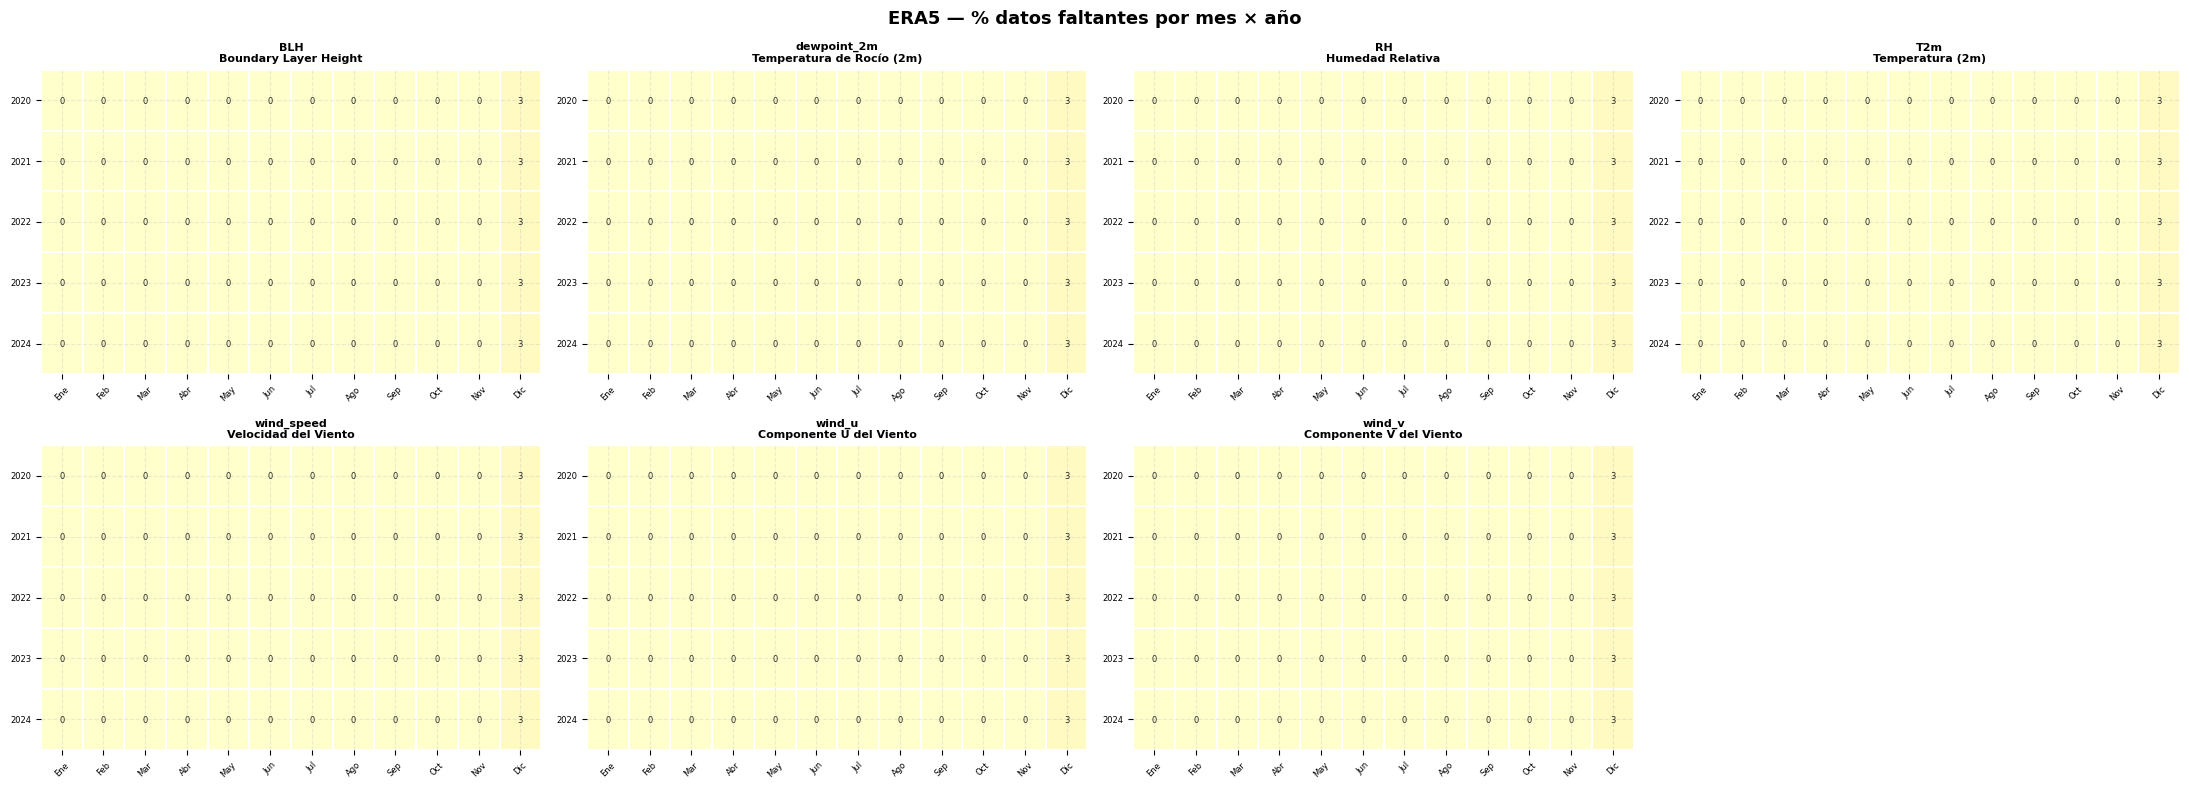

💾  era5_missing.png guardado


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 1 — CALIDAD: DATOS FALTANTES
# ══════════════════════════════════════════════════════════════════════════════

print("📊 CALIDAD DE DATOS\n" + "─"*50)
for var, df in DATA.items():
    if df.empty: continue
    n_miss = df['missing'].sum()
    pct    = df['missing'].mean() * 100
    print(f"  {var:<12} {df['value'].notna().mean()*100:5.1f}% cobertura  |  {n_miss} días faltantes")

# Heatmap de faltantes año × mes para cada variable
fig, axes = plt.subplots(2, 4, figsize=(22, 8))
axes = axes.flatten()
fig.suptitle("ERA5 — % datos faltantes por mes × año", fontsize=13, fontweight='bold')

for ax, var in zip(axes, VARIABLES):
    df = DATA[var]
    if df.empty:
        ax.axis('off'); continue
    tabla = df.groupby(['anio','mes'])['missing'].mean().unstack() * 100
    tabla.columns = MESES_ES
    tabla.index   = tabla.index.astype(str)
    sns.heatmap(tabla, ax=ax, annot=True, fmt=".0f",
                cmap='YlOrRd', vmin=0, vmax=100,
                linewidths=0.3, cbar=False,
                annot_kws={'size': 6})
    ax.set_title(f"{var}\n{VARIABLES[var]['nombre']}", fontsize=8, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.tick_params(axis='y', rotation=0,  labelsize=6)
    ax.set_xlabel(""); ax.set_ylabel("")

axes[-1].axis('off')
plt.tight_layout()
plt.savefig("era5_missing.png", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()
print("💾  era5_missing.png guardado")

## 3. Series Temporales Completas (2020–2024)

Series diarias con medias móviles de 7 y 30 días para suavizar el ruido y revelar tendencias. Los percentiles P10 y P90 son referencias de valores extremos habituales. El sombreado de área refleja la variabilidad bruta día a día.

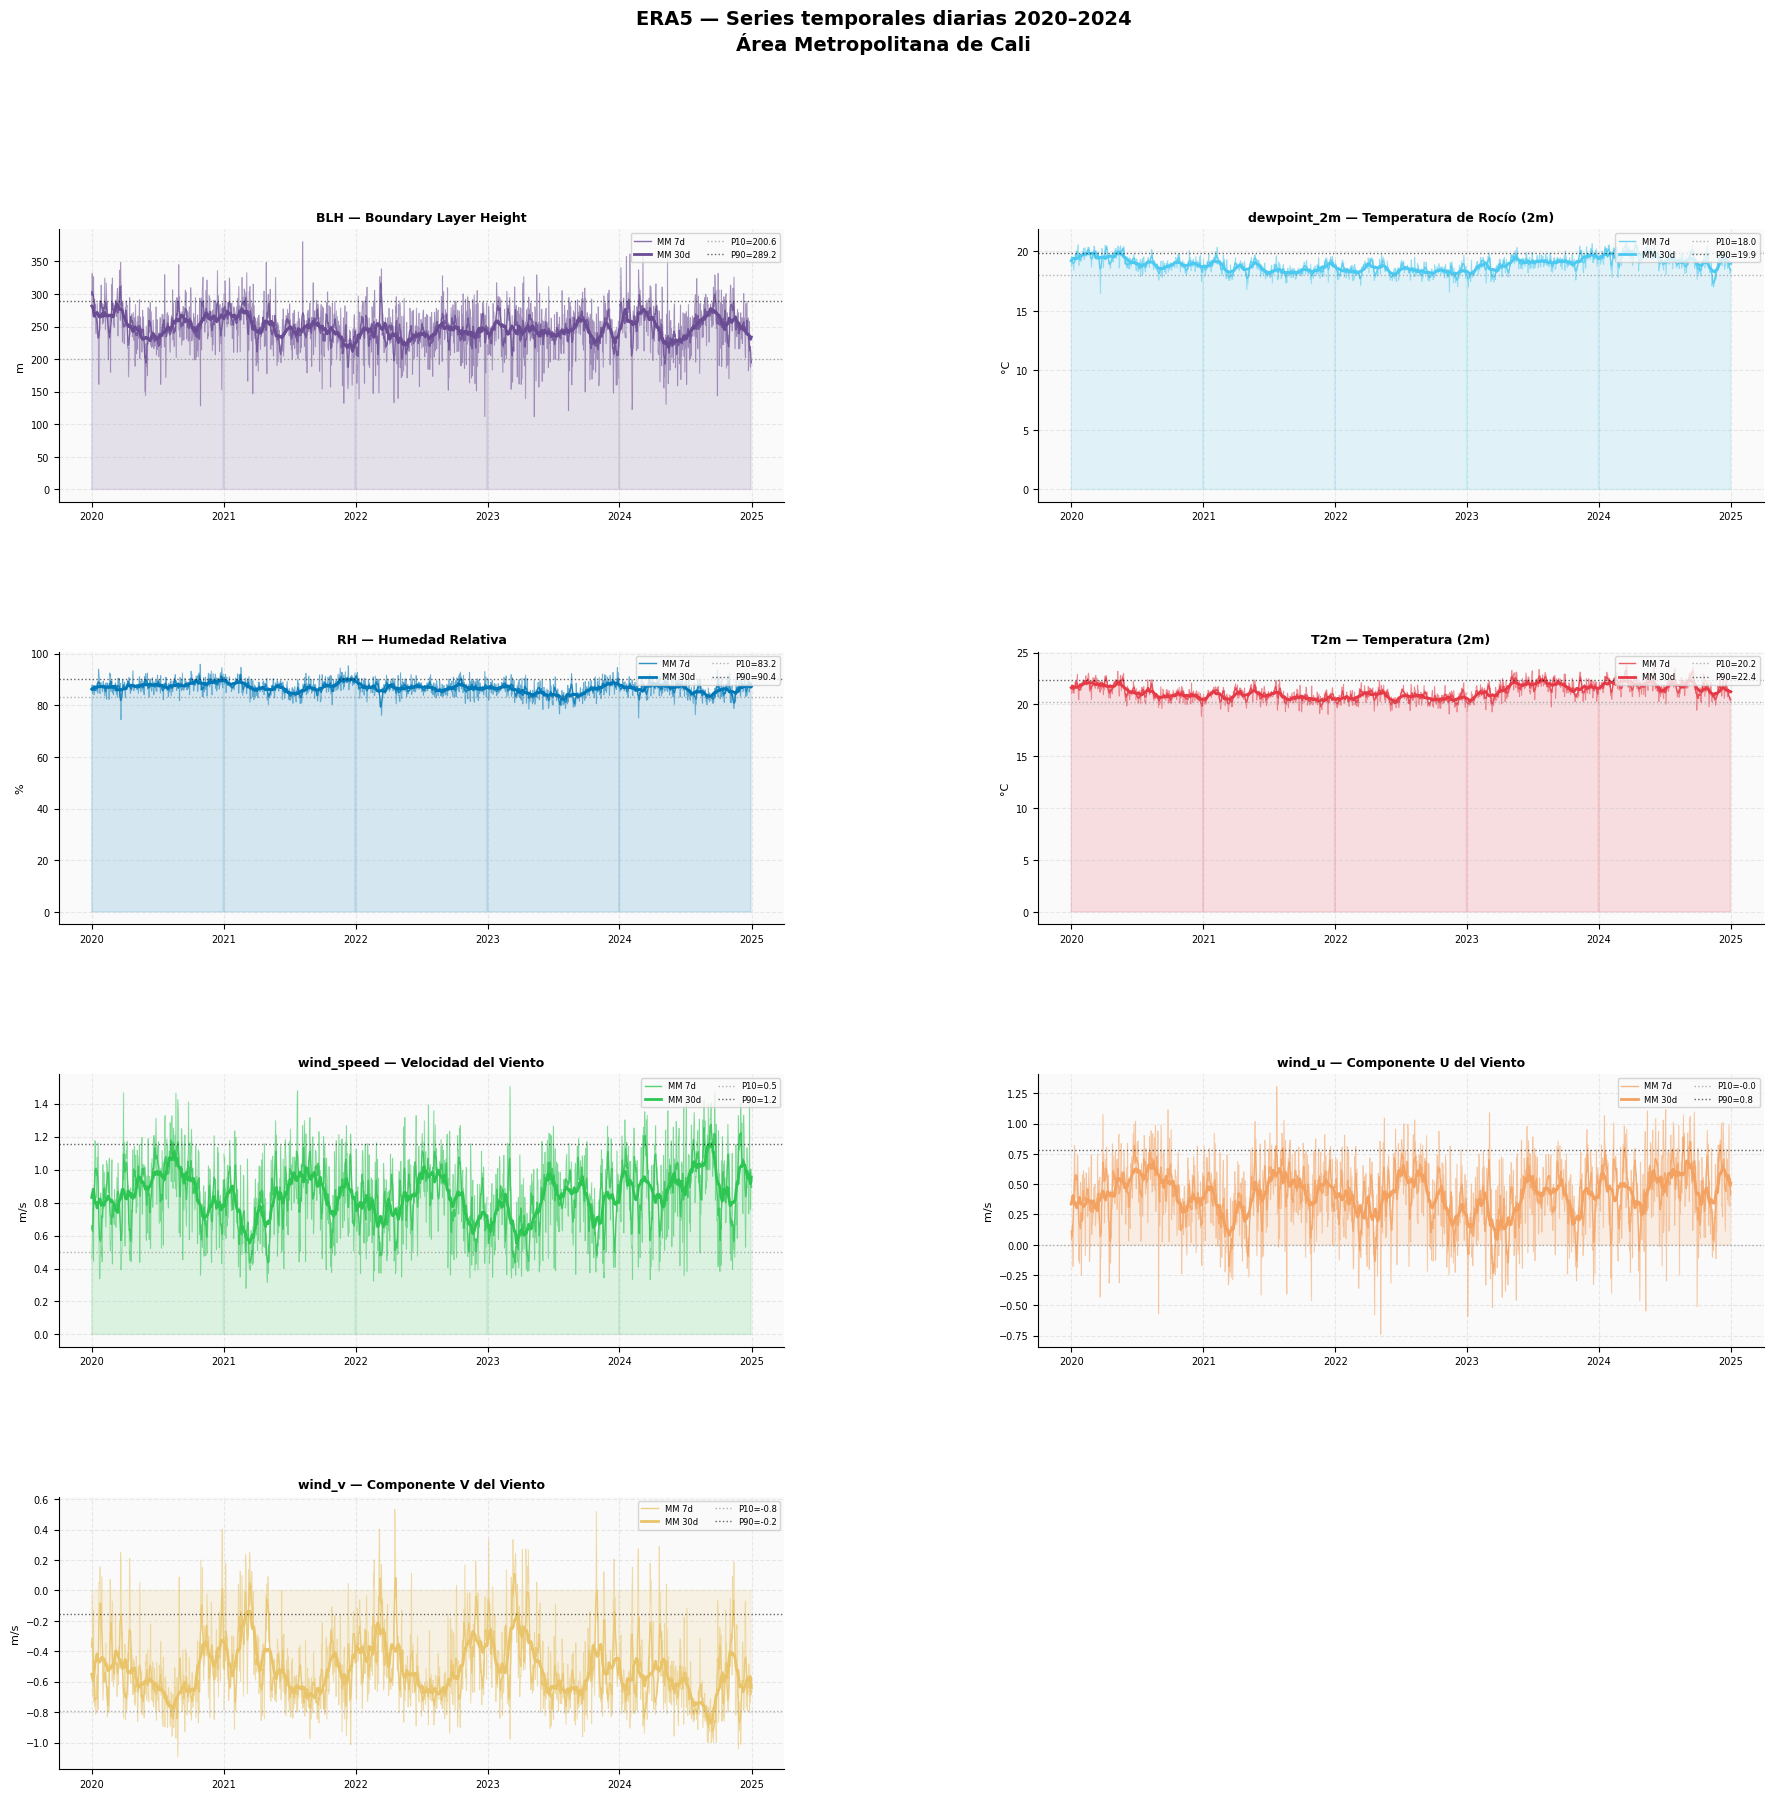

💾  era5_series.png guardado


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 2 — SERIES TEMPORALES COMPLETAS
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 20), facecolor='white')
fig.suptitle("ERA5 — Series temporales diarias 2020–2024\nÁrea Metropolitana de Cali",
             fontsize=14, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35)

posiciones = [(0,0),(0,1),(1,0),(1,1),(2,0),(2,1),(3,0)]

for (r,c), var in zip(posiciones, VARIABLES):
    df  = DATA[var]
    cfg = VARIABLES[var]
    if df.empty: continue

    ax = fig.add_subplot(gs[r, c])
    df['mm30'] = df['value'].rolling(30, center=True, min_periods=5).mean()
    df['mm7']  = df['value'].rolling(7,  center=True, min_periods=3).mean()

    ax.fill_between(df['date'], df['value'], alpha=0.15, color=cfg["color"])
    ax.plot(df['date'], df['value'], lw=0.5, color=cfg["color"], alpha=0.5)
    ax.plot(df['date'], df['mm7'],   lw=1.0, color=cfg["color"], alpha=0.8, label='MM 7d')
    ax.plot(df['date'], df['mm30'],  lw=2.0, color=cfg["color"], alpha=1.0, label='MM 30d')

    # Percentiles P10/P90
    p10 = df['value'].quantile(0.10)
    p90 = df['value'].quantile(0.90)
    ax.axhline(p10, ls=':', lw=1, color='gray',  alpha=0.6, label=f'P10={p10:.1f}')
    ax.axhline(p90, ls=':', lw=1, color='black', alpha=0.6, label=f'P90={p90:.1f}')

    ax.set_title(f"{var} — {cfg['nombre']}", fontweight='bold', fontsize=9)
    ax.set_ylabel(cfg["unidad"], fontsize=8)
    ax.legend(fontsize=6, ncol=2, loc='upper right')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(labelsize=7)

# Eje vacío para wind_v (posición 3,1)
fig.add_subplot(gs[3, 1]).axis('off')

plt.savefig("era5_series.png", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()
print("💾  era5_series.png guardado")

## 4. Estacionalidad Mensual

Ciclo anual de cada variable: barras con la media histórica ± desviación estándar y líneas superpuestas por año. Permite detectar si hay diferencias interanuales o si el ciclo es estable. Clave para entender cómo cambia el contexto meteorológico que modula la concentración de contaminantes.

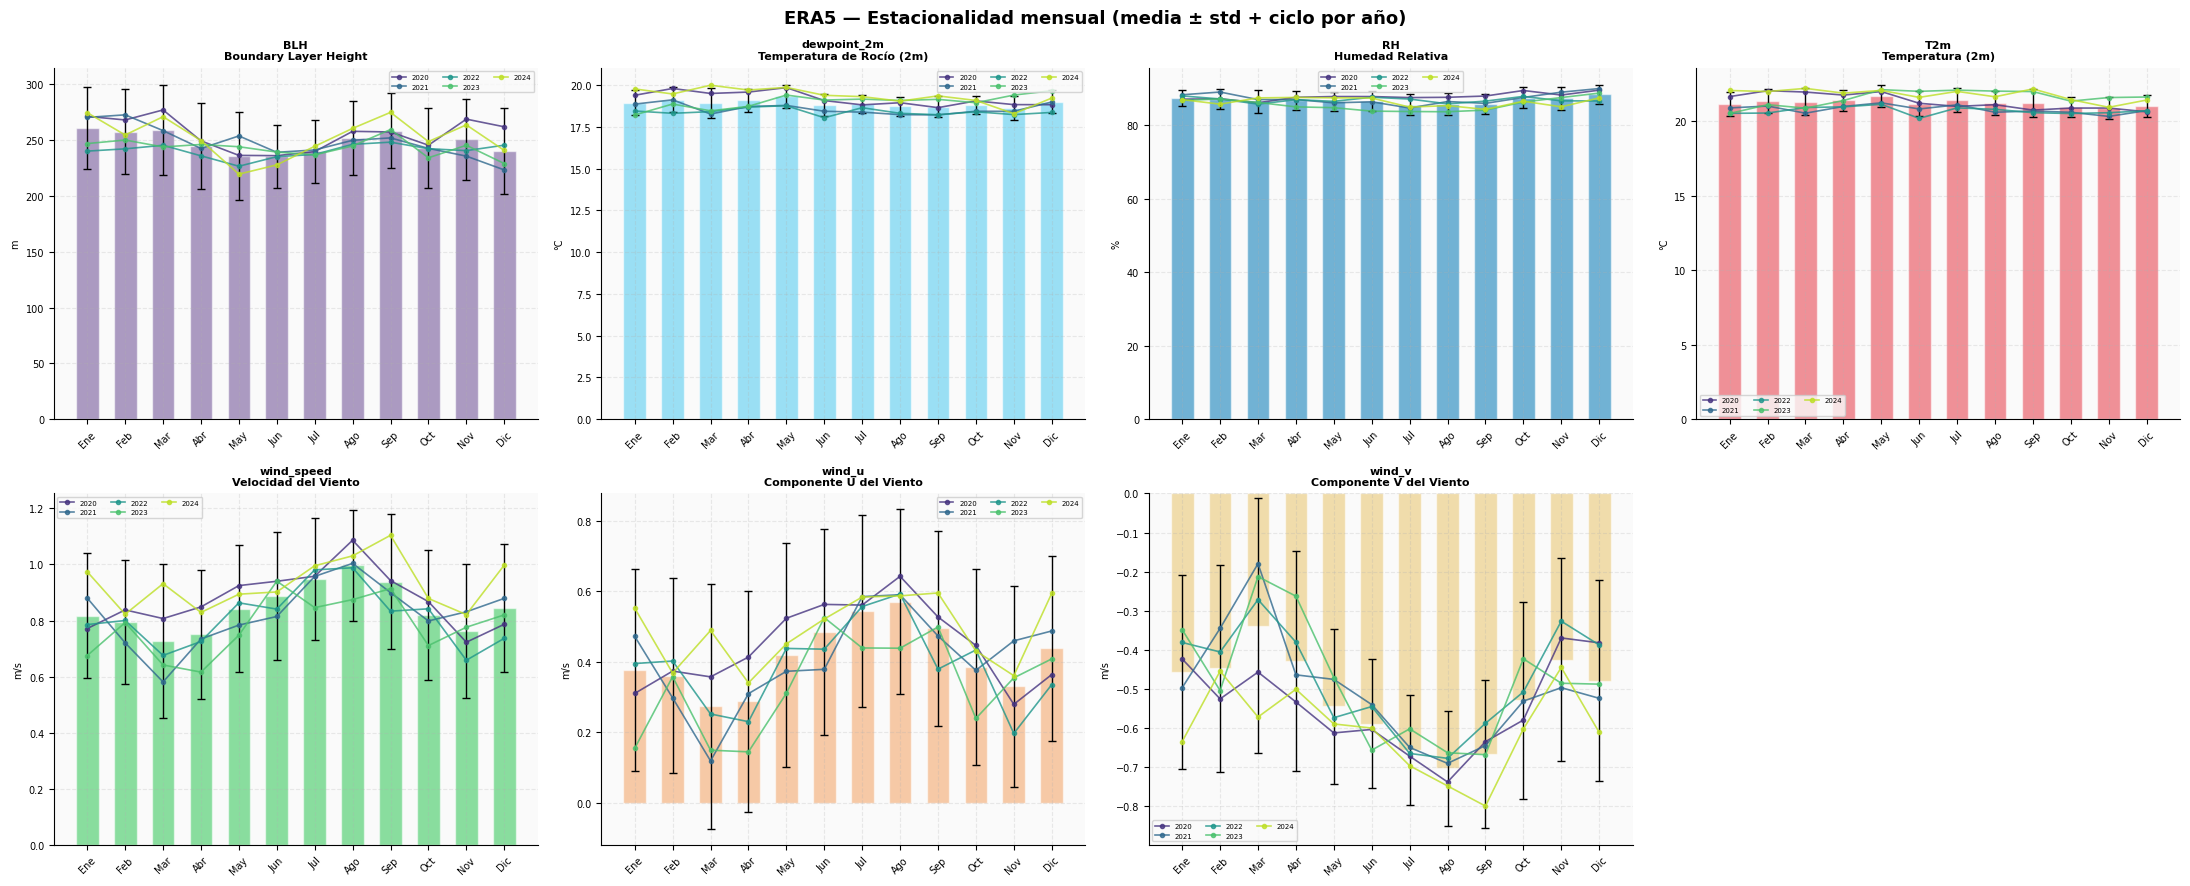

💾  era5_estacionalidad.png guardado


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 3 — ESTACIONALIDAD MENSUAL
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(22, 9), facecolor='white')
axes = axes.flatten()
fig.suptitle("ERA5 — Estacionalidad mensual (media ± std + ciclo por año)",
             fontsize=13, fontweight='bold')

for ax, var in zip(axes, VARIABLES):
    df  = DATA[var]
    cfg = VARIABLES[var]
    if df.empty: ax.axis('off'); continue

    grp    = df.groupby('mes')['value']
    medias = grp.mean()
    stds   = grp.std()

    ax.bar(range(1,13), medias, color=cfg["color"], alpha=0.55,
           edgecolor='white', width=0.6)
    ax.errorbar(range(1,13), medias, yerr=stds, fmt='none',
                color='black', capsize=3, lw=1)

    palette = plt.cm.viridis(np.linspace(0.15, 0.9, len(AÑOS)))
    for anio, pal_c in zip(AÑOS, palette):
        dfa = df[df['anio'] == anio].groupby('mes')['value'].mean()
        ax.plot(dfa.index, dfa.values, 'o-', ms=3, lw=1.2,
                color=pal_c, alpha=0.8, label=str(anio))

    ax.set_xticks(range(1,13))
    ax.set_xticklabels(MESES_ES, fontsize=6, rotation=45)
    ax.set_title(f"{var}\n{cfg['nombre']}", fontsize=8, fontweight='bold')
    ax.set_ylabel(cfg["unidad"], fontsize=7)
    ax.legend(fontsize=5, ncol=3, loc='best')
    ax.tick_params(labelsize=7)

axes[-1].axis('off')
plt.tight_layout()
plt.savefig("era5_estacionalidad.png", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()
print("💾  era5_estacionalidad.png guardado")


## 5. Anomalías Mensuales

Para cada mes se calcula la diferencia entre la media del mes-año y la media histórica del mes. El heatmap (año × mes) revela qué períodos fueron inusualmente cálidos, húmedos o ventosos. Anomalías positivas en BLH, por ejemplo, indican mayor dilución de contaminantes ese mes.

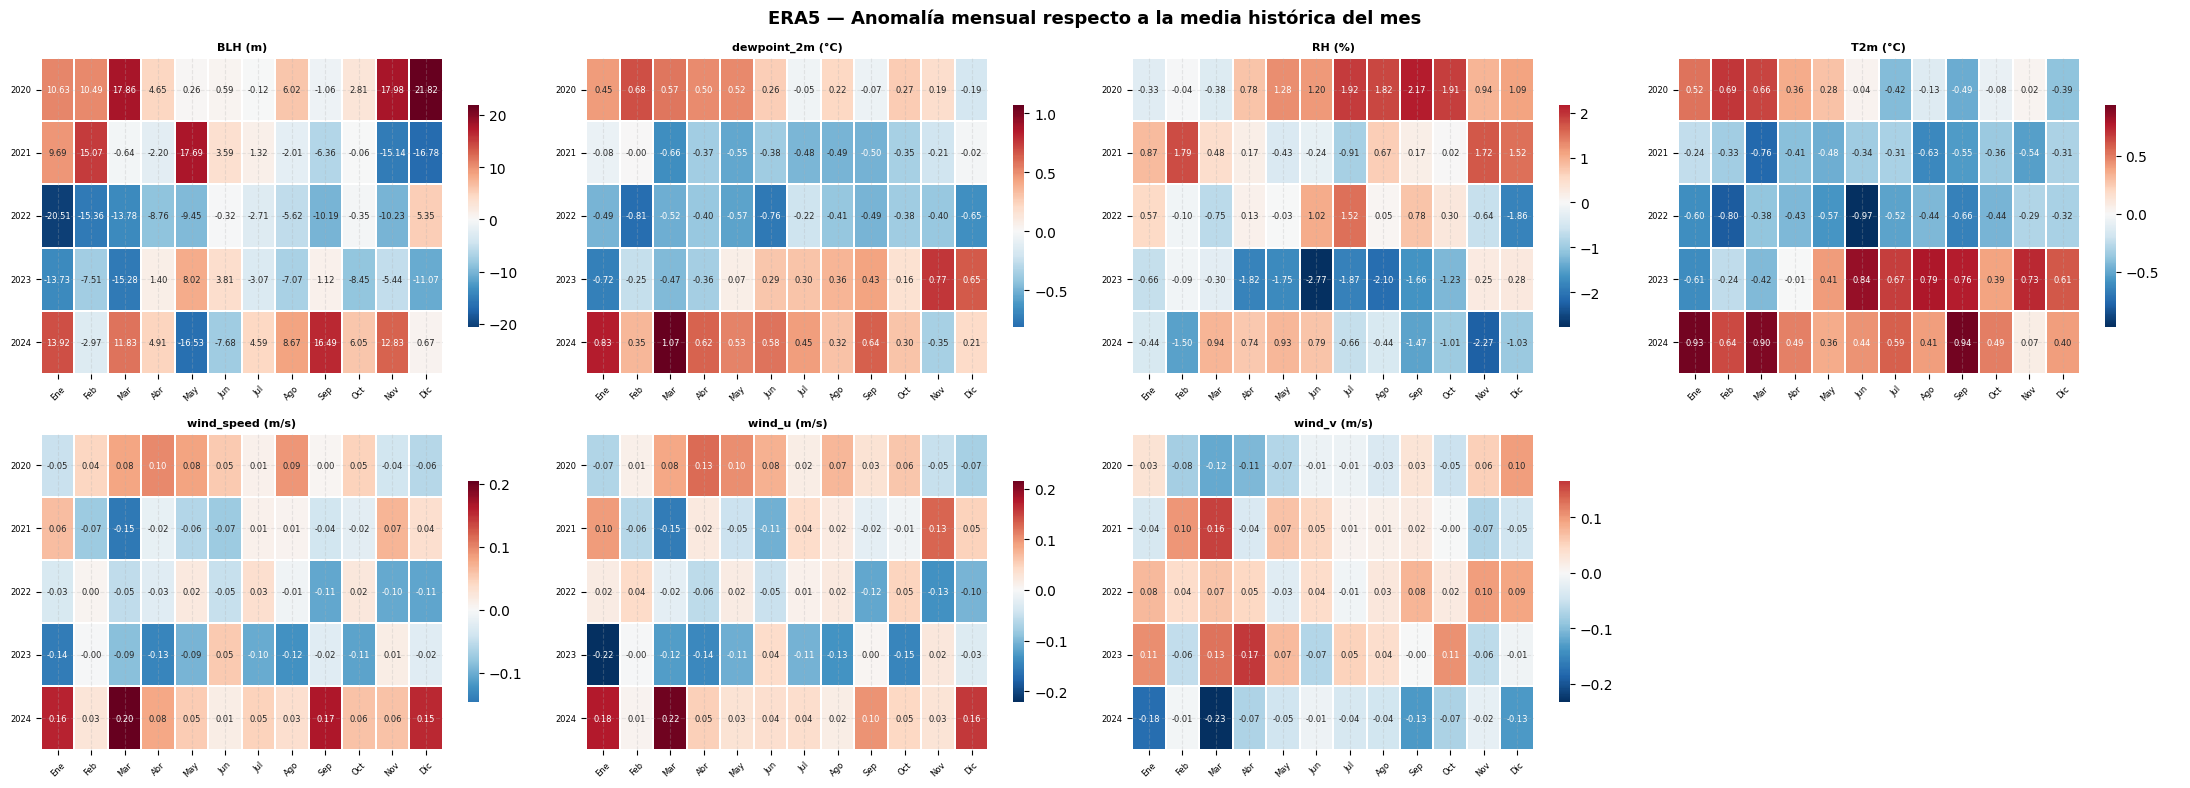

💾  era5_anomalias.png guardado


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 4 — ANOMALÍAS MENSUALES (heatmap año × mes)
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(22, 8), facecolor='white')
axes = axes.flatten()
fig.suptitle("ERA5 — Anomalía mensual respecto a la media histórica del mes",
             fontsize=13, fontweight='bold')

for ax, var in zip(axes, VARIABLES):
    df  = DATA[var]
    if df.empty: ax.axis('off'); continue
    cfg = VARIABLES[var]

    media_mes  = df.groupby('mes')['value'].transform('mean')
    df['anom'] = df['value'] - media_mes
    pivot = df.groupby(['anio','mes'])['anom'].mean().unstack()
    pivot.columns = MESES_ES
    pivot.index   = pivot.index.astype(str)

    sns.heatmap(pivot, ax=ax, cmap='RdBu_r', center=0,
                annot=True, fmt=".2f", linewidths=0.3,
                cbar_kws={'shrink': 0.7},
                annot_kws={'size': 6})
    ax.set_title(f"{var} ({cfg['unidad']})", fontsize=8, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.tick_params(axis='y', rotation=0,  labelsize=6)
    ax.set_xlabel(""); ax.set_ylabel("")

axes[-1].axis('off')
plt.tight_layout()
plt.savefig("era5_anomalias.png", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()
print("💾  era5_anomalias.png guardado")

## 6. Distribución y Outliers

Por variable:
- **Histograma + KDE** vs. distribución normal teórica: evalúa asimetría y colas pesadas.
- **Q-Q plot**: cuantifica la desviación de la normalidad (R² de la regresión cuantil-cuantil).
- **Boxplot por año**: detecta outliers y cambios interanuales de dispersión.

Los outliers por IQR×1.5 son especialmente relevantes para BLH y velocidad del viento, que siguen distribuciones sesgadas.

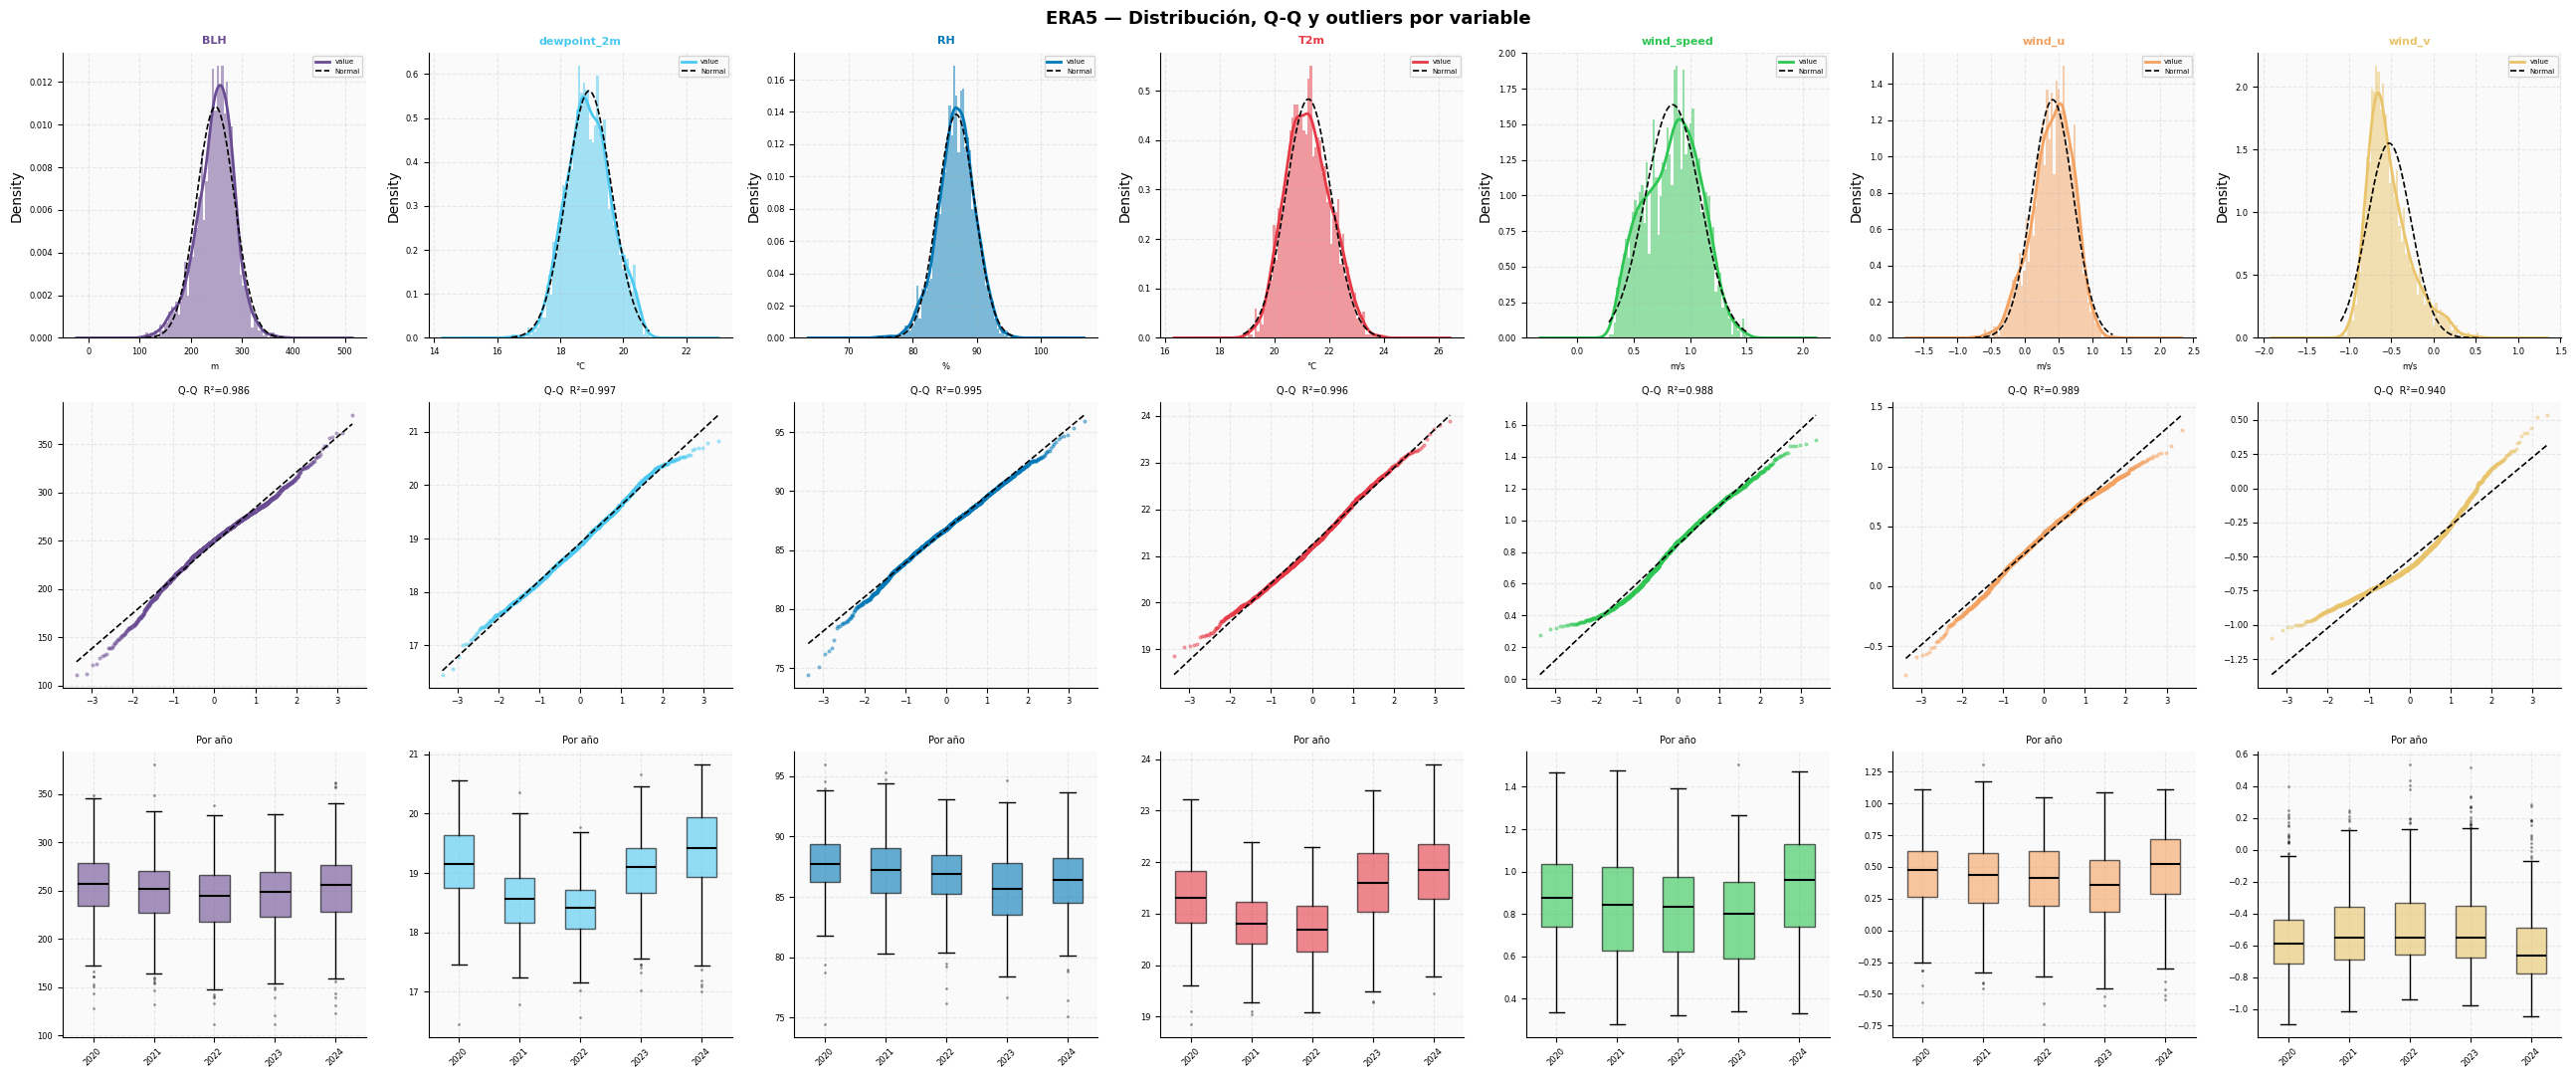

💾  era5_distribucion.png guardado


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 5 — DISTRIBUCIÓN Y OUTLIERS
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 7, figsize=(26, 11), facecolor='white')
fig.suptitle("ERA5 — Distribución, Q-Q y outliers por variable",
             fontsize=13, fontweight='bold')

for col, var in enumerate(VARIABLES):
    df  = DATA[var]
    cfg = VARIABLES[var]
    if df.empty: continue
    vals  = df['value'].dropna()
    color = cfg["color"]

    # Histograma + KDE
    ax = axes[0, col]
    ax.hist(vals, bins=60, color=color, alpha=0.5, density=True, edgecolor='none')
    vals.plot.kde(ax=ax, color=color, lw=2)
    mu, sigma = vals.mean(), vals.std()
    x = np.linspace(vals.min(), vals.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k--', lw=1.2, label='Normal')
    ax.set_title(var, fontsize=8, fontweight='bold', color=color)
    ax.set_xlabel(cfg["unidad"], fontsize=6)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=5)

    # Q-Q plot
    ax = axes[1, col]
    (osm, osr), (slope, intercept, r) = stats.probplot(vals, dist='norm')
    ax.scatter(osm, osr, s=4, color=color, alpha=0.4)
    ax.plot([osm[0], osm[-1]],
            [slope*osm[0]+intercept, slope*osm[-1]+intercept],
            'k--', lw=1.2)
    ax.set_title(f"Q-Q  R²={r**2:.3f}", fontsize=7)
    ax.tick_params(labelsize=6)

    # Boxplot por año
    ax = axes[2, col]
    datos_año = [df.loc[df['anio'] == a, 'value'].dropna().values for a in AÑOS]
    bp = ax.boxplot(datos_año, patch_artist=True,
                    medianprops=dict(color='black', lw=1.5),
                    flierprops=dict(marker='.', markersize=2, alpha=0.4))
    for patch in bp['boxes']:
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.set_xticklabels(AÑOS, fontsize=5, rotation=45)
    ax.set_title("Por año", fontsize=7)
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig("era5_distribucion.png", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()
print("💾  era5_distribucion.png guardado")

## 7. Correlación entre Variables ERA5

Matrices de correlación de Pearson y Spearman entre las 7 variables. La comparación entre ambas métricas permite identificar relaciones no lineales. Se espera correlación negativa entre BLH y humedad relativa, y positiva entre temperatura y temperatura de rocío.

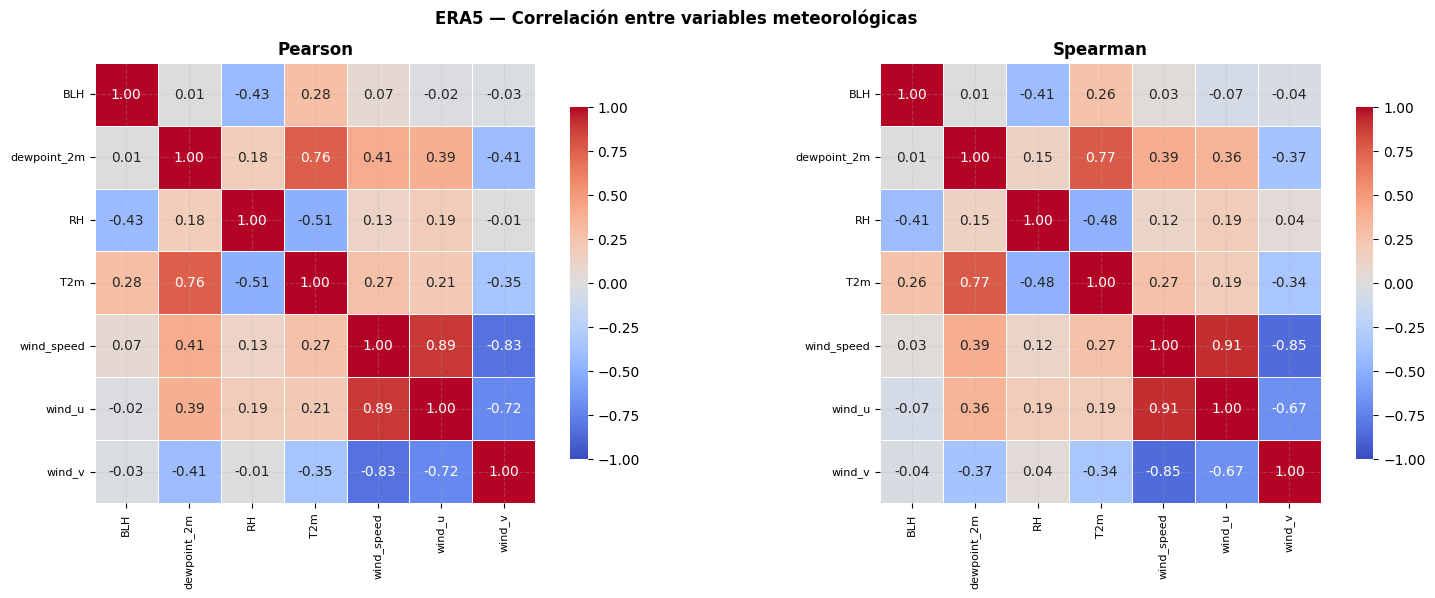

💾  era5_correlacion_interna.png guardado


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 6 — CORRELACIÓN ENTRE VARIABLES ERA5
# ══════════════════════════════════════════════════════════════════════════════

vars_list = [v for v in VARIABLES if not DATA[v].empty]
corr_mat  = df_all[vars_list].corr(method='pearson')
corr_sp   = df_all[vars_list].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')
fig.suptitle("ERA5 — Correlación entre variables meteorológicas",
             fontsize=12, fontweight='bold')

for ax, mat, titulo in zip(axes,
                            [corr_mat, corr_sp],
                            ['Pearson', 'Spearman']):
    mask = np.triu(np.ones_like(mat, dtype=bool), k=1)
    sns.heatmap(mat, ax=ax, annot=True, fmt=".2f",
                cmap='coolwarm', center=0, vmin=-1, vmax=1,
                linewidths=0.5, square=True,
                cbar_kws={'shrink': 0.8})
    ax.set_title(titulo, fontweight='bold')
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("era5_correlacion_interna.png", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()
print("💾  era5_correlacion_interna.png guardado")

## 8. Rosa de Vientos y Componentes U/V

Análisis vectorial del viento: la rosa polar muestra la frecuencia de cada dirección predominante; el scatter U vs. V coloreado por velocidad revela los regímenes de circulación. Relevante para entender la dirección de transporte de contaminantes hacia o desde el área urbana de Cali.

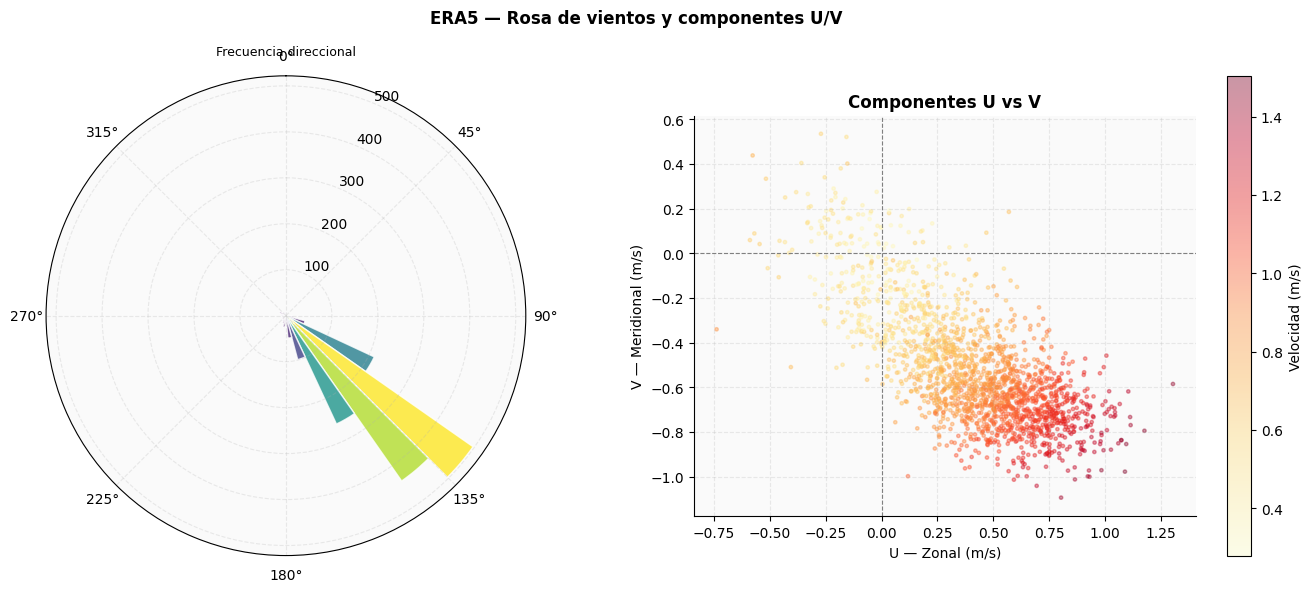

💾  era5_viento.png guardado


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 7 — ROSA DE VIENTOS (wind_u + wind_v)
# ══════════════════════════════════════════════════════════════════════════════

if 'wind_u' in DATA and 'wind_v' in DATA and \
   not DATA['wind_u'].empty and not DATA['wind_v'].empty:

    wu = DATA['wind_u'][['date','value']].rename(columns={'value':'u'})
    wv = DATA['wind_v'][['date','value']].rename(columns={'value':'v'})
    df_w = wu.merge(wv, on='date').merge(
               DATA['wind_speed'][['date','value']].rename(columns={'value':'spd'}),
               on='date')
    df_w['dir_rad'] = np.arctan2(df_w['u'], df_w['v'])   # dirección meteoro
    df_w['dir_deg'] = np.degrees(df_w['dir_rad']) % 360

    fig = plt.figure(figsize=(14, 6), facecolor='white')
    fig.suptitle("ERA5 — Rosa de vientos y componentes U/V",
                 fontsize=12, fontweight='bold')

    # Rosa de vientos polar
    ax_polar = fig.add_subplot(121, projection='polar')
    n_bins_dir = 36
    bins_dir   = np.linspace(0, 360, n_bins_dir + 1)
    counts, _  = np.histogram(df_w['dir_deg'], bins=bins_dir)
    theta      = np.radians(bins_dir[:-1])
    bars       = ax_polar.bar(theta, counts, width=2*np.pi/n_bins_dir,
                               color=plt.cm.viridis(counts / counts.max()),
                               alpha=0.8, edgecolor='white')
    ax_polar.set_theta_zero_location('N')
    ax_polar.set_theta_direction(-1)
    ax_polar.set_title("Frecuencia direccional", fontsize=9, pad=15)

    # Scatter U vs V coloreado por velocidad
    ax_sc = fig.add_subplot(122)
    sc = ax_sc.scatter(df_w['u'], df_w['v'],
                       c=df_w['spd'], cmap='YlOrRd', s=6, alpha=0.4)
    plt.colorbar(sc, ax=ax_sc, label='Velocidad (m/s)')
    ax_sc.axhline(0, color='gray', lw=0.8, ls='--')
    ax_sc.axvline(0, color='gray', lw=0.8, ls='--')
    ax_sc.set_xlabel("U — Zonal (m/s)")
    ax_sc.set_ylabel("V — Meridional (m/s)")
    ax_sc.set_title("Componentes U vs V", fontweight='bold')
    ax_sc.set_aspect('equal')

    plt.tight_layout()
    plt.savefig("era5_viento.png", dpi=140, bbox_inches='tight', facecolor='white')
    plt.show()
    print("💾  era5_viento.png guardado")


## 9. Análisis Especial — BLH (Boundary Layer Height)

La altura de la capa límite es la variable más directamente relacionada con la dispersión de contaminantes: BLH baja (<500 m) comprime los contaminantes en un volumen reducido, elevando las concentraciones. Se analiza la serie temporal, distribución mensual, clasificación por régimen (alto/bajo) y el porcentaje de días críticos por mes.

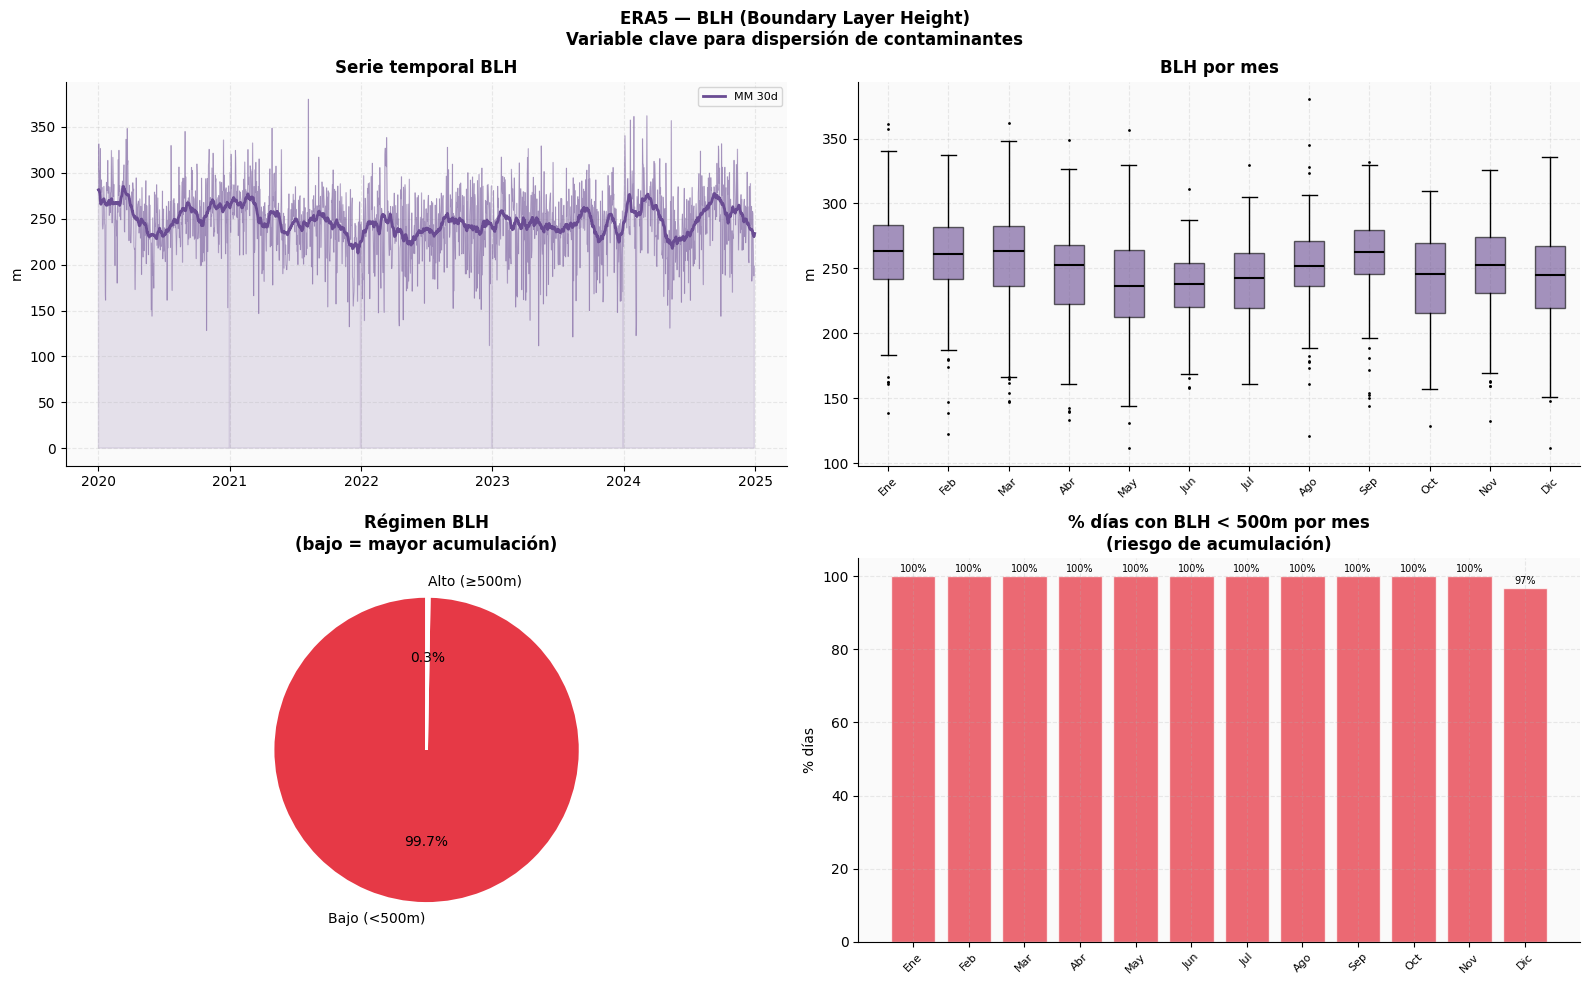

💾  era5_blh.png guardado


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 8 — BLH: ANÁLISIS ESPECIAL
# (controla directamente la dilución de contaminantes)
# ══════════════════════════════════════════════════════════════════════════════

if 'BLH' in DATA and not DATA['BLH'].empty:
    df_blh = DATA['BLH'].copy()
    df_blh['mm30'] = df_blh['value'].rolling(30, center=True, min_periods=5).mean()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='white')
    fig.suptitle("ERA5 — BLH (Boundary Layer Height)\n"
                 "Variable clave para dispersión de contaminantes",
                 fontsize=12, fontweight='bold')

    # Serie temporal
    ax = axes[0, 0]
    ax.fill_between(df_blh['date'], df_blh['value'], alpha=0.15, color='#6a4c93')
    ax.plot(df_blh['date'], df_blh['value'], lw=0.5, color='#6a4c93', alpha=0.5)
    ax.plot(df_blh['date'], df_blh['mm30'],  lw=2,   color='#6a4c93', label='MM 30d')
    ax.set_title("Serie temporal BLH", fontweight='bold')
    ax.set_ylabel("m"); ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # Boxplot mensual
    ax = axes[0, 1]
    datos_mes = [df_blh.loc[df_blh['mes']==m,'value'].dropna().values for m in range(1,13)]
    bp = ax.boxplot(datos_mes, patch_artist=True,
                    medianprops=dict(color='black', lw=1.5),
                    flierprops=dict(marker='.', markersize=2))
    for patch in bp['boxes']:
        patch.set_facecolor('#6a4c93'); patch.set_alpha(0.6)
    ax.set_xticklabels(MESES_ES, fontsize=8, rotation=45)
    ax.set_title("BLH por mes", fontweight='bold')
    ax.set_ylabel("m")

    # Clasificación por umbral de mezcla
    # BLH < 500m → capa límite baja → acumulación de contaminantes
    ax = axes[1, 0]
    umbral_bajo = 500
    df_blh['regimen'] = np.where(df_blh['value'] < umbral_bajo,
                                  'Bajo (<500m)', 'Alto (≥500m)')
    conteo = df_blh['regimen'].value_counts()
    colores_reg = ['#e63946', '#2dc653']
    ax.pie(conteo, labels=conteo.index, autopct='%1.1f%%',
           colors=colores_reg, startangle=90,
           wedgeprops={'edgecolor':'white','lw':2})
    ax.set_title("Régimen BLH\n(bajo = mayor acumulación)", fontweight='bold')

    # % días BLH bajo por mes
    ax = axes[1, 1]
    pct_bajo = df_blh.groupby('mes').apply(
        lambda g: (g['value'] < umbral_bajo).mean() * 100)
    bars = ax.bar(MESES_ES, pct_bajo, color='#e63946', alpha=0.75, edgecolor='white')
    for bar, pct in zip(bars, pct_bajo):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{pct:.0f}%", ha='center', va='bottom', fontsize=7)
    ax.set_title("% días con BLH < 500m por mes\n(riesgo de acumulación)",
                 fontweight='bold')
    ax.set_ylabel("% días")
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    plt.tight_layout()
    plt.savefig("era5_blh.png", dpi=140, bbox_inches='tight', facecolor='white')
    plt.show()
    print("💾  era5_blh.png guardado")

## 10. Análisis Espectral — Periodicidades Dominantes

Periodograma de Welch para identificar las frecuencias con mayor potencia en cada serie. Se marcan períodos de referencia (7d, 30d, 6m, 1 año). Los picos en rojo corresponden a las periodicidades más energéticas: ciclos sinópticos, intraestacionales o anuales.

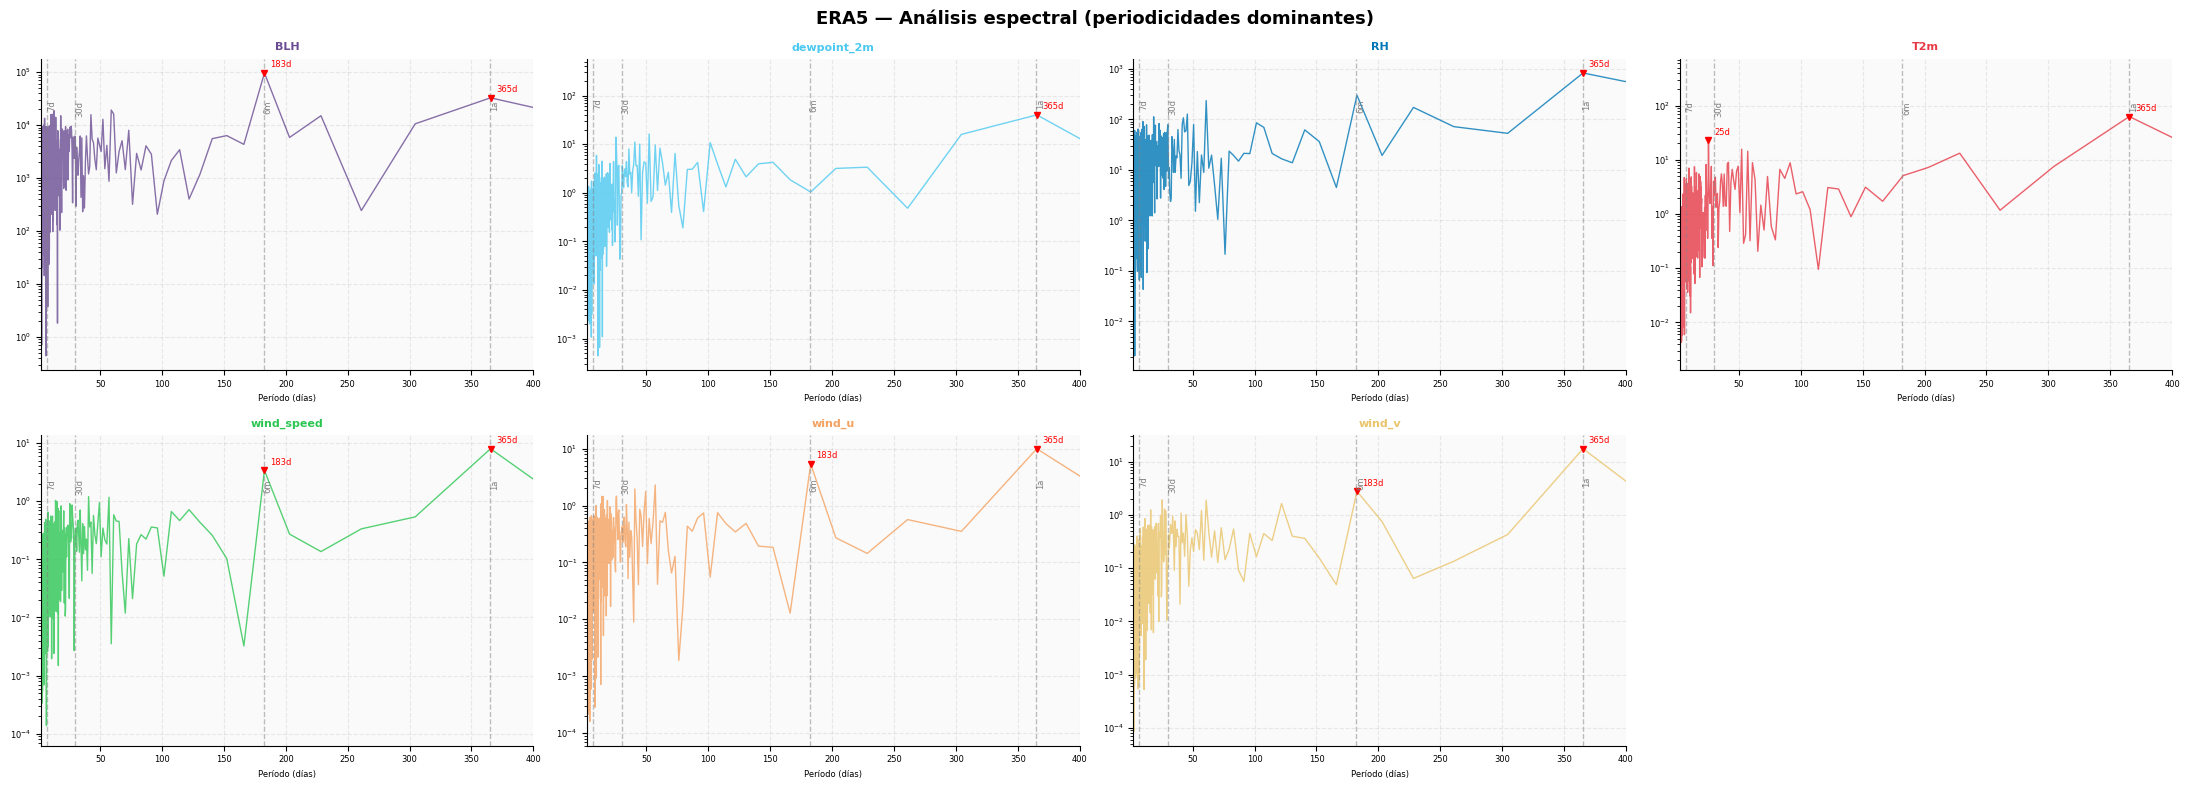

💾  era5_espectral.png guardado


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 10 — ANÁLISIS ESPECTRAL
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(22, 8), facecolor='white')
axes = axes.flatten()
fig.suptitle("ERA5 — Análisis espectral (periodicidades dominantes)",
             fontsize=13, fontweight='bold')

for ax, var in zip(axes, VARIABLES):
    df  = DATA[var]
    cfg = VARIABLES[var]
    if df.empty: ax.axis('off'); continue

    serie = (df['value']
             .interpolate(method='linear')
             .ffill().bfill())
    freqs, potencia = periodogram(serie, fs=1.0)
    periodos = 1.0 / freqs[1:]
    potencia  = potencia[1:]

    ax.semilogy(periodos, potencia, color=cfg["color"], lw=1, alpha=0.8)
    for p_ref, lbl in [(7,'7d'),(30,'30d'),(182,'6m'),(365,'1a')]:
        ax.axvline(p_ref, color='gray', ls='--', lw=1, alpha=0.5)
        ax.text(p_ref, potencia.max()*0.3, lbl,
                fontsize=6, rotation=90, va='top', color='gray')

    # Top 3 picos
    for ip in np.argsort(potencia)[-3:]:
        ax.plot(periodos[ip], potencia[ip], 'rv', ms=5)
        ax.annotate(f"{periodos[ip]:.0f}d",
                    (periodos[ip], potencia[ip]),
                    xytext=(4,4), textcoords='offset points',
                    fontsize=6, color='red')

    ax.set_xlim(2, 400)
    ax.set_title(f"{var}", fontsize=8, fontweight='bold', color=cfg["color"])
    ax.set_xlabel("Período (días)", fontsize=6)
    ax.tick_params(labelsize=6)

axes[-1].axis('off')
plt.tight_layout()
plt.savefig("era5_espectral.png", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()
print("💾  era5_espectral.png guardado")

## 12. Resumen Ejecutivo

Estadísticas descriptivas clave por variable: cobertura de datos, media, mediana, coeficiente de variación, rango, número de outliers, test de normalidad Shapiro-Wilk y tendencia lineal anual con significancia estadística.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# RESUMEN EJECUTIVO
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═"*65)
print("  RESUMEN EJECUTIVO — ERA5 / Cali  2020–2024")
print("═"*65)

for var in VARIABLES:
    df  = DATA[var]
    cfg = VARIABLES[var]
    if df.empty: continue
    v = df['value'].dropna()

    sw   = stats.shapiro(v.sample(min(500, len(v)), random_state=42))
    q1, q3 = v.quantile(0.25), v.quantile(0.75)
    n_out  = ((v < q1-1.5*(q3-q1)) | (v > q3+1.5*(q3-q1))).sum()
    tend, _, _, p_tend, _ = stats.linregress(np.arange(len(v)), v.values)

    print(f"""
  {var} — {cfg['nombre']} ({cfg['unidad']})
  {cfg['desc']}
    Cobertura  : {df['value'].notna().mean()*100:.1f}%
    Media      : {v.mean():.3f}  |  Mediana: {v.median():.3f}
    Std / CV   : {v.std():.3f}  /  {v.std()/abs(v.mean())*100:.1f}%
    Rango      : [{v.min():.3f}, {v.max():.3f}]
    Outliers   : {n_out} ({n_out/len(v)*100:.1f}%)
    Normalidad : Shapiro p={sw.pvalue:.2e}  {"→ NO normal" if sw.pvalue<0.05 else "→ Normal"}
    Tendencia  : {tend*365:.4f} {cfg['unidad']}/año  (p={p_tend:.3e})""")


═════════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO — ERA5 / Cali  2020–2024
═════════════════════════════════════════════════════════════════

  BLH — Boundary Layer Height (m)
  Altura de la capa límite — controla la dilución de contaminantes
    Cobertura  : 99.7%
    Media      : 247.992  |  Mediana: 251.468
    Std / CV   : 36.800  /  14.8%
    Rango      : [111.515, 380.288]
    Outliers   : 36 (2.0%)
    Normalidad : Shapiro p=2.49e-05  → NO normal
    Tendencia  : -1.5859 m/año  (p=7.998e-03)

  dewpoint_2m — Temperatura de Rocío (2m) (°C)
  Indica el contenido de vapor de agua
    Cobertura  : 99.7%
    Media      : 18.917  |  Mediana: 18.894
    Std / CV   : 0.710  /  3.8%
    Rango      : [16.454, 20.822]
    Outliers   : 3 (0.2%)
    Normalidad : Shapiro p=2.10e-01  → Normal
    Tendencia  : 0.0643 °C/año  (p=2.292e-08)

  RH — Humedad Relativa (%)
  Humedad relativa — favorece reacciones húmedas de SO2/NO2
    Cobertura  : 99.7%
    Media